# **Project Name**    - Ford GoBike Trip Data - Exploratory Data Analysis



##### **Project Type**    - EDA
##### **Contribution**    - Individual/Team


# **Project Summary -**

This project analyzes 1.86 million Ford GoBike trips recorded across California (San Francisco Bay Area) from January to December 2018. The dataset includes 16 variables covering trip duration, start and end timestamps, station locations, bike IDs, user type (Subscriber vs Customer), and rider demographics such as birth year and gender.

The goal was to explore usage patterns and generate insights that could help the business optimize bike distribution, pricing, and marketing strategy.

Data wrangling involved converting timestamps into proper datetime format, deriving new features such as trip duration in minutes, rider age, hour of day, day of week, month, and a weekend flag. Missing values were found mainly in station information (~11,000-12,000 rows) and rider demographics (~110,000 rows for birth year and gender), consistent with casual customers who don't provide profile details.

Exploratory analysis through 15 visualizations revealed several key patterns. Ride volume shows sharp peaks around 8-9 AM and 5-6 PM on weekdays, closely matching typical work commute times, and is significantly higher on weekdays than weekends. Around 85% of all trips come from Subscribers (registered members), while only 15% come from Customers (casual, one-time riders). Subscribers show short, consistent trip durations and strong weekday commute patterns, while Customers show longer, more variable trip durations with relatively more weekend usage, indicating leisure-oriented behavior.

Ride volume and average trip duration both increase during warmer months and decline in winter, showing that weather significantly affects usage. A small number of central, transit-adjacent stations account for a disproportionately large share of both pickups and drop-offs, making them critical points for bike availability and rebalancing. Rider demographics skew toward ages 25-40 and are predominantly male, though a meaningful share of gender data was unspecified.

A correlation heatmap and pair plot of the numeric variables (duration, age, hour, month) showed weak linear relationships between them, suggesting that trip behavior is better explained by categorical factors like user type and day of week rather than by these numeric variables in isolation.

Based on these findings, business recommendations include prioritizing bike rebalancing at high-traffic stations ahead of peak commute hours, designing weekend and leisure-focused promotions to convert Customers into Subscribers, planning seasonal fleet maintenance during low-demand winter months, and investigating unusually long trips as potential lost or damaged bikes. Overall, this analysis confirms GoBike operates as a commute-first service with a loyal subscriber base, while highlighting clear opportunities to grow casual ridership into recurring subscriptions.

# **GitHub Link -**

Provide your GitHub Link here.

# **Problem Statement**


Ford GoBike faces challenges in understanding rider behavior, peak demand patterns, and station-level usage across its bike-sharing network. Without clear insight into when, where, and by whom bikes are used, it is difficult to plan bike availability, pricing, and marketing effectively.

#### **Define Your Business Objective?**

To analyze one year (2018) of Ford GoBike trip data to identify usage patterns by time, location, and user type, and to generate actionable insights that help optimize bike distribution, improve rider retention, and support data-driven business decisions.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 20 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
import glob
%matplotlib inline

### Dataset Loading

In [2]:
# Load Dataset
import zipfile

def read_zip_csv(filepath):
    with zipfile.ZipFile(filepath) as z:
        # Find the actual csv file (ignore junk like __MACOSX)
        csv_names = [n for n in z.namelist() if n.endswith('.csv') and '__MACOSX' not in n]
        with z.open(csv_names[0]) as f:
            return pd.read_csv(f)

files = glob.glob('*.zip')
print(files)
print(len(files), "files found")

dfs = [read_zip_csv(f) for f in files]
df = pd.concat(dfs, ignore_index=True)

print(df.shape)

import os
for f in os.listdir():
    print(repr(f))

['201801-fordgobike-tripdata.csv.zip', '201802-fordgobike-tripdata.csv.zip', '201803-fordgobike-tripdata.csv.zip', '201804-fordgobike-tripdata.csv.zip', '201805-fordgobike-tripdata.csv.zip', '201806-fordgobike-tripdata.csv.zip', '201807-fordgobike-tripdata.csv.zip', '201808-fordgobike-tripdata.csv.zip', '201809-fordgobike-tripdata.csv..zip', '201810-fordgobike-tripdata.csv.zip', '201811-fordgobike-tripdata.csv.zip', '201812-fordgobike-tripdata.csv.zip']
12 files found
(1863721, 16)
'.ipynb_checkpoints'
'201801-fordgobike-tripdata.csv.zip'
'201802-fordgobike-tripdata.csv.zip'
'201803-fordgobike-tripdata.csv.zip'
'201804-fordgobike-tripdata.csv.zip'
'201805-fordgobike-tripdata.csv.zip'
'201806-fordgobike-tripdata.csv.zip'
'201807-fordgobike-tripdata.csv.zip'
'201808-fordgobike-tripdata.csv.zip'
'201809-fordgobike-tripdata.csv..zip'
'201810-fordgobike-tripdata.csv.zip'
'201811-fordgobike-tripdata.csv.zip'
'201812-fordgobike-tripdata.csv.zip'
'Sample_EDA_Submission_Template.ipynb'


### Dataset First View

In [3]:
# Dataset First Look
df.head()

,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip
0,75284,2018-01-31 22:52:35.2390,2018-02-01 19:47:19.8240,120.0,Mission Dolores Park,37.761420,-122.426435,285.0,Webster St at O'Farrell St,37.783521,-122.431158,2765,Subscriber,1986.0,Male,No
1,85422,2018-01-31 16:13:34.3510,2018-02-01 15:57:17.3100,15.0,San Francisco Ferry Building (Harry Bridges Pl...,37.795392,-122.394203,15.0,San Francisco Ferry Building (Harry Bridges Pl...,37.795392,-122.394203,2815,Customer,NaN,NaN,No
2,71576,2018-01-31 14:23:55.8890,2018-02-01 10:16:52.1160,304.0,Jackson St at 5th St,37.348759,-121.894798,296.0,5th St at Virginia St,37.325998,-121.877120,3039,Customer,1996.0,Male,No
3,61076,2018-01-31 14:53:23.5620,2018-02-01 07:51:20.5000,75.0,Market St at Franklin St,37.773793,-122.421239,47.0,4th St at Harrison St,37.780955,-122.399749,321,Customer,NaN,NaN,No
4,39966,2018-01-31 19:52:24.6670,2018-02-01 06:58:31.0530,74.0,Laguna St at Hayes St,37.776435,-122.426244,19.0,Post St at Kearny St,37.788975,-122.403452,617,Subscriber,1991.0,Male,No


### Dataset Rows & Columns count

In [4]:
# Dataset Rows & Columns count
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 1863721
Columns: 16


### Dataset Information

In [5]:
# Dataset Info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1863721 entries, 0 to 1863720
Data columns (total 16 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   duration_sec             int64  
 1   start_time               str    
 2   end_time                 str    
 3   start_station_id         float64
 4   start_station_name       str    
 5   start_station_latitude   float64
 6   start_station_longitude  float64
 7   end_station_id           float64
 8   end_station_name         str    
 9   end_station_latitude     float64
 10  end_station_longitude    float64
 11  bike_id                  int64  
 12  user_type                str    
 13  member_birth_year        float64
 14  member_gender            str    
 15  bike_share_for_all_trip  str    
dtypes: float64(7), int64(2), str(7)
memory usage: 437.6 MB


#### Duplicate Values

In [6]:
# Dataset Duplicate Value Count
df.duplicated().sum()

np.int64(0)

#### Missing Values/Null Values

In [7]:
# Missing Values/Null Values Count
df.isnull().sum()

duration_sec                    0
start_time                      0
end_time                        0
start_station_id            11771
start_station_name          11771
start_station_latitude          0
start_station_longitude         0
end_station_id              11771
end_station_name            11771
end_station_latitude            0
end_station_longitude           0
bike_id                         0
user_type                       0
member_birth_year          110718
member_gender              110367
bike_share_for_all_trip         0
dtype: int64

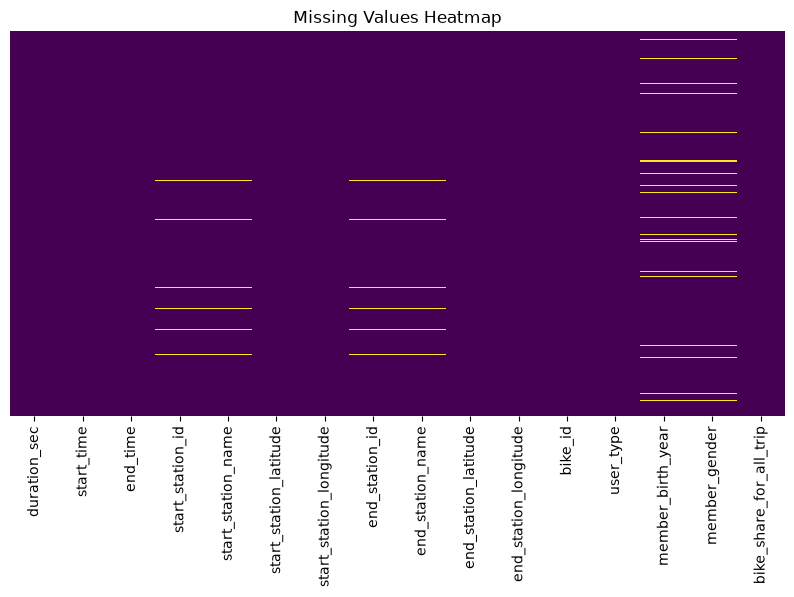

In [8]:
# Visualizing the missing values
plt.figure(figsize=(10,5))
sb.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

### What did you know about your dataset?
.

Is dataset mein January se December 2018 tak ke Ford GoBike trips ka data hai (1,863,721 rows, 16 columns). Har row ek trip represent karti hai. Duplicate rows nahi hain. Missing values sirf station info (~11,000-12,000 rows) aur rider demographics - birth year, gender (~110,000 rows) mein hain, jo customers ne profile fill nahi ki unke liye common hai

## ***2. Understanding Your Variables***

In [9]:
# Dataset Columns
df.columns.tolist()

['duration_sec',
 'start_time',
 'end_time',
 'start_station_id',
 'start_station_name',
 'start_station_latitude',
 'start_station_longitude',
 'end_station_id',
 'end_station_name',
 'end_station_latitude',
 'end_station_longitude',
 'bike_id',
 'user_type',
 'member_birth_year',
 'member_gender',
 'bike_share_for_all_trip']

In [10]:
# Dataset Describe
df.describe()

,duration_sec,start_station_id,start_station_latitude,start_station_longitude,end_station_id,end_station_latitude,end_station_longitude,bike_id,member_birth_year
count,1.863721e+06,1.851950e+06,1.863721e+06,1.863721e+06,1.851950e+06,1.863721e+06,1.863721e+06,1.863721e+06,1.753003e+06
mean,8.573026e+02,1.196744e+02,3.776678e+01,-1.223492e+02,1.181730e+02,3.776690e+01,-1.223487e+02,2.296851e+03,1.983088e+03
std,2.370379e+03,1.003976e+02,1.057689e-01,1.654634e-01,1.004403e+02,1.056483e-01,1.650597e-01,1.287733e+03,1.044289e+01
min,6.100000e+01,3.000000e+00,3.726331e+01,-1.224737e+02,3.000000e+00,3.726331e+01,-1.224737e+02,1.100000e+01,1.881000e+03
25%,3.500000e+02,3.300000e+01,3.777106e+01,-1.224114e+02,3.000000e+01,3.777106e+01,-1.224094e+02,1.225000e+03,1.978000e+03
50%,5.560000e+02,8.900000e+01,3.778107e+01,-1.223974e+02,8.800000e+01,3.778127e+01,-1.223971e+02,2.338000e+03,1.985000e+03
75%,8.720000e+02,1.860000e+02,3.779625e+01,-1.222865e+02,1.830000e+02,3.779728e+01,-1.222894e+02,3.333000e+03,1.991000e+03
max,8.636600e+04,3.810000e+02,4.551000e+01,-7.357000e+01,3.810000e+02,4.551000e+01,-7.357000e+01,6.234000e+03,2.000000e+03


### Variables Description

- duration_sec: Trip duration in seconds
- start_time, end_time: Trip start and end timestamps
- start_station_id/name/latitude/longitude: Where the trip started
- end_station_id/name/latitude/longitude: Where the trip ended
- bike_id: Unique ID of the bike used
- user_type: Subscriber (member) or Customer (casual rider)
- member_birth_year: Rider's birth year (used to calculate age)
- member_gender: Male, Female, or Other
- bike_share_for_all_trip: Whether the trip was part of a subsidized bike-share program for low-income riders

### Check Unique Values for each variable.

In [11]:
# Check Unique Values for each variable.
for col in df.columns:
    print(col, ":", df[col].nunique(), "unique values")

duration_sec : 16709 unique values
start_time : 1863584 unique values
end_time : 1863610 unique values
start_station_id : 331 unique values
start_station_name : 348 unique values
start_station_latitude : 369 unique values
start_station_longitude : 370 unique values
end_station_id : 331 unique values
end_station_name : 348 unique values
end_station_latitude : 370 unique values
end_station_longitude : 371 unique values
bike_id : 5054 unique values
user_type : 2 unique values
member_birth_year : 86 unique values
member_gender : 3 unique values
bike_share_for_all_trip : 2 unique values


## 3. ***Data Wrangling***

### Data Wrangling Code

In [12]:
# Write your code to make your dataset analysis ready.
# Convert timestamps to datetime
df['start_time'] = pd.to_datetime(df['start_time'])
df['end_time'] = pd.to_datetime(df['end_time'])

# Duration in minutes (easier to read than seconds)
df['duration_min'] = df['duration_sec'] / 60

# Rider age
df['age'] = 2018 - df['member_birth_year']

# Extract time-based features
df['start_hour'] = df['start_time'].dt.hour
df['start_dow'] = df['start_time'].dt.day_name()
df['start_month'] = df['start_time'].dt.month
df['is_weekend'] = df['start_time'].dt.dayofweek >= 5

# Check the new columns
df[['duration_min','age','start_hour','start_dow','start_month','is_weekend']].head()

,duration_min,age,start_hour,start_dow,start_month,is_weekend
0,1254.733333,32.0,22,Wednesday,1,False
1,1423.700000,NaN,16,Wednesday,1,False
2,1192.933333,22.0,14,Wednesday,1,False
3,1017.933333,NaN,14,Wednesday,1,False
4,666.100000,27.0,19,Wednesday,1,False


### What all manipulations have you done and insights you found?

Converted timestamps to proper datetime format so hour/day/month could be extracted. Converted duration from seconds to minutes for easier interpretation. Calculated rider age from birth year. Created a weekend flag to compare weekday vs weekend usage. These new columns will help us see peak hours, seasonal trends, and user behavior patterns.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

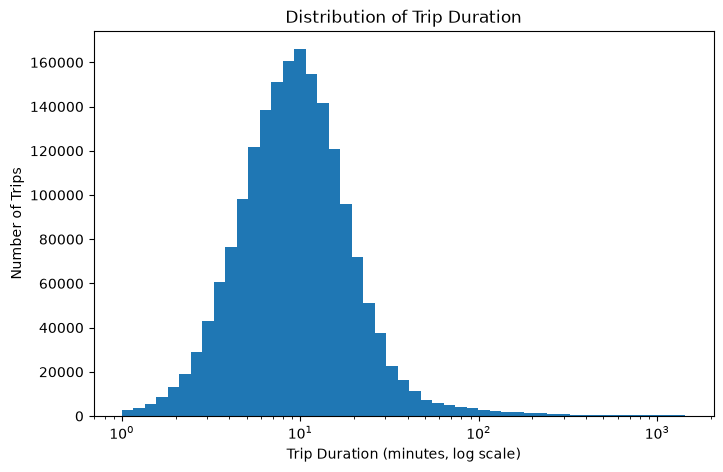

In [13]:
# Chart - 1 visualization code
plt.figure(figsize=(8,5))
bins = 10**np.linspace(0, np.log10(df.duration_min.max()), 50)
plt.hist(df.duration_min, bins=bins)
plt.xscale('log')
plt.xlabel('Trip Duration (minutes, log scale)')
plt.ylabel('Number of Trips')
plt.title('Distribution of Trip Duration')
plt.show()

##### 1. Why did you pick the specific chart?

A histogram with log scale was chosen because trip duration is heavily right-skewed — most trips are short, but a few outlier trips last hours. Log scale makes the pattern visible instead of one giant bar near zero.

##### 2. What is/are the insight(s) found from the chart?

Most trips last between 5 to 15 minutes, with the distribution peaking around 8-10 minutes. There is a long tail of longer trips, some lasting several hours, which are likely rare or unusual usage (forgotten check-ins, lost bikes, etc.).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Knowing that most trips are short helps optimize bike availability near short-trip zones and set reasonable trip time limits/pricing tiers. It also flags outlier long trips as an area to investigate for lost or damaged bikes, which could otherwise cause a negative cost impact if ignored.

#### Chart - 2

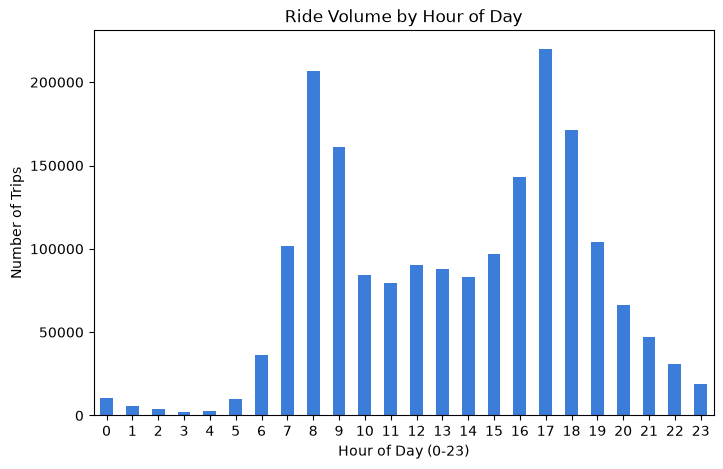

In [14]:
# Chart - 2 visualization code
plt.figure(figsize=(8,5))
df.start_hour.value_counts().sort_index().plot(kind='bar', color='#3b7dd8')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Number of Trips')
plt.title('Ride Volume by Hour of Day')
plt.xticks(rotation=0)
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart was chosen because hour of day is a discrete categorical variable (0-23), and bar charts clearly show volume differences across each hour.

##### 2. What is/are the insight(s) found from the chart?

Ride volume shows two clear peaks - around 8-9 AM and 5-6 PM, which line up with typical work commute times. Usage is lowest between 1 AM and 4 AM.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. This confirms GoBike is heavily used for commuting. The company can prioritize bike redistribution before these two peak windows to avoid station shortages, and can schedule maintenance during the low-usage overnight hours to minimize disruption.

#### Chart - 3

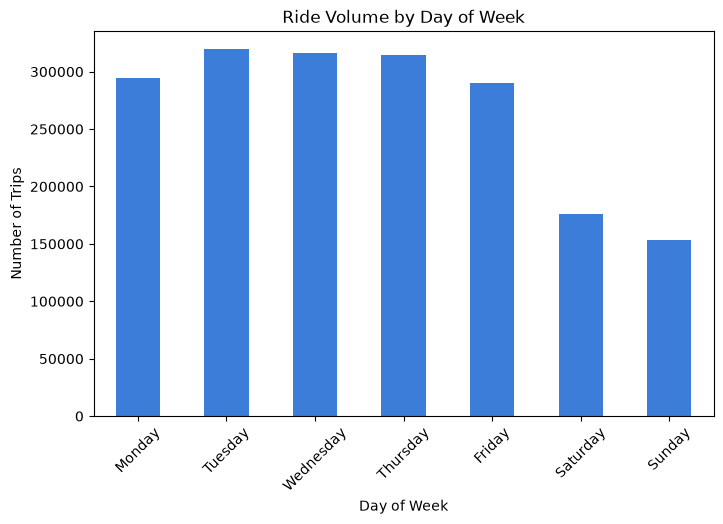

In [15]:
# Chart - 3 visualization code
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
plt.figure(figsize=(8,5))
df.start_dow.value_counts().reindex(dow_order).plot(kind='bar', color='#3b7dd8')
plt.xlabel('Day of Week')
plt.ylabel('Number of Trips')
plt.title('Ride Volume by Day of Week')
plt.xticks(rotation=45)
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart was used since day of week is categorical, making it easy to compare ride counts across the seven days.

##### 2. What is/are the insight(s) found from the chart?

Weekdays (Monday to Friday) have noticeably higher ride volume than weekends (Saturday, Sunday). This further supports that GoBike is primarily used for commuting rather than leisure.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. This helps plan bike supply and staffing differently for weekdays vs weekends. Weekend promotions could be considered to boost leisure ridership and balance demand across the week.

#### Chart - 4

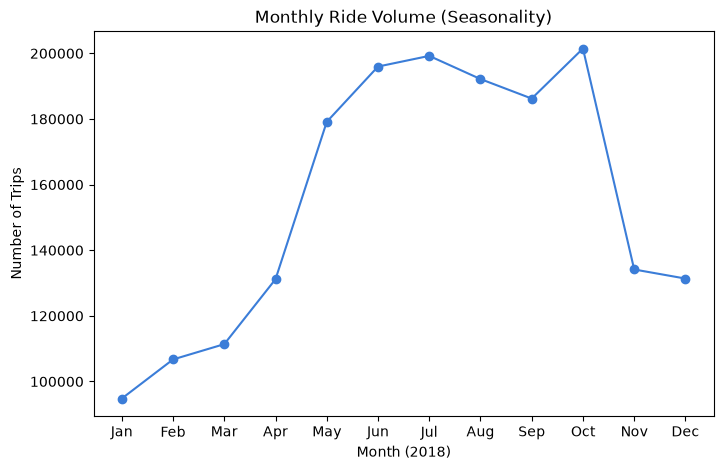

In [16]:
# Chart - 4 visualization code
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
plt.figure(figsize=(8,5))
counts = df.start_month.value_counts().sort_index()
plt.plot([month_names[i-1] for i in counts.index], counts.values, marker='o', color='#3b7dd8')
plt.xlabel('Month (2018)')
plt.ylabel('Number of Trips')
plt.title('Monthly Ride Volume (Seasonality)')
plt.show()

##### 1. Why did you pick the specific chart?

A line chart was chosen because month has a natural sequential order, and a line best shows the trend/seasonality over time.

##### 2. What is/are the insight(s) found from the chart?

Ride volume is lowest in the early months (Jan-Feb) and steadily increases through the year, peaking around mid-to-late year (summer/fall), before declining slightly toward December. This suggests weather has a real effect on ridership.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The company can plan fleet expansion, marketing, and maintenance schedules around this seasonal pattern - investing more in bike availability during high-demand months and using low-demand months for fleet servicing.

#### Chart - 5

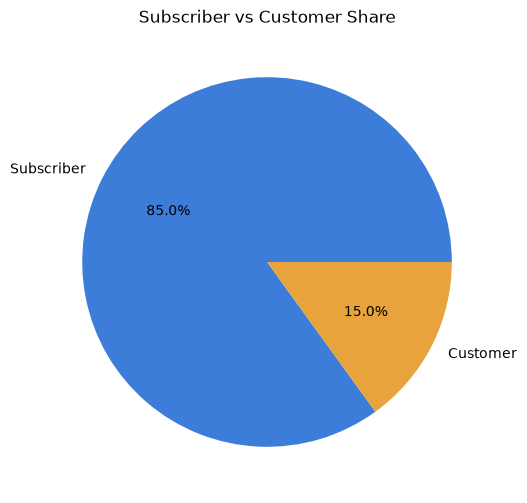

In [17]:
# Chart - 5 visualization code
plt.figure(figsize=(6,6))
df.user_type.value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['#3b7dd8','#e8a33d'], ylabel='')
plt.title('Subscriber vs Customer Share')
plt.show()

##### 1. Why did you pick the specific chart?

A pie chart was used because user_type has only two categories, making a pie chart an intuitive way to show their proportional share of total trips.

##### 2. What is/are the insight(s) found from the chart?

The large majority of trips (around 85%) are made by Subscribers (regular members), while only about 15% come from Customers (casual, one-time riders).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. This shows the business relies heavily on its subscriber base, meaning retention programs for subscribers are critical. It also highlights an opportunity - converting more casual Customers into Subscribers could meaningfully grow recurring revenue.

#### Chart - 6

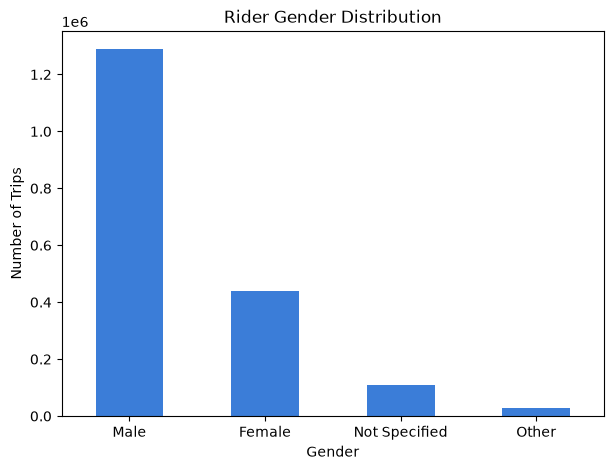

In [18]:
# Chart - 6 visualization code
plt.figure(figsize=(7,5))
df.member_gender.value_counts(dropna=False).rename(index={np.nan:'Not Specified'}).plot(kind='bar', color='#3b7dd8')
plt.xlabel('Gender')
plt.ylabel('Number of Trips')
plt.title('Rider Gender Distribution')
plt.xticks(rotation=0)
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart was used since gender is a categorical variable with a few distinct groups, making counts easy to compare.

##### 2. What is/are the insight(s) found from the chart?

The majority of riders identify as Male, followed by Female, with a small share as Other. A notable number of trips also have gender Not Specified, matching the missing values seen earlier.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. This highlights a gender gap in ridership. The company could design targeted marketing or safety features to encourage more female and non-binary riders, expanding its overall user base.

#### Chart - 7

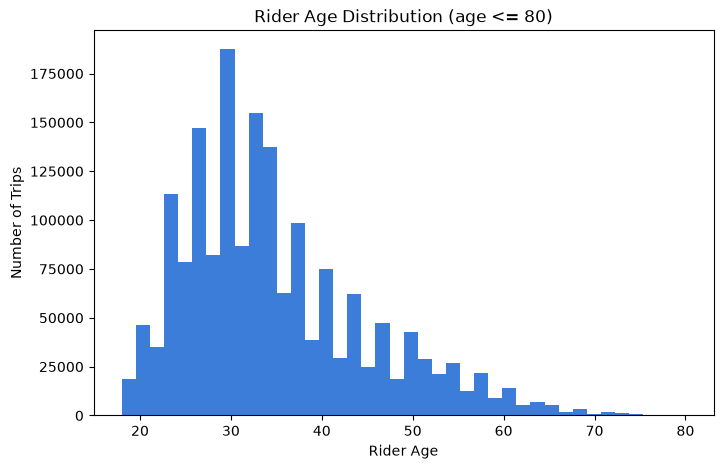

In [19]:
# Chart - 7 visualization code
plt.figure(figsize=(8,5))
plt.hist(df[df.age<=80].age.dropna(), bins=40, color='#3b7dd8')
plt.xlabel('Rider Age')
plt.ylabel('Number of Trips')
plt.title('Rider Age Distribution (age <= 80)')
plt.show()

##### 1. Why did you pick the specific chart?

A histogram was chosen since age is a continuous numeric variable, and a histogram best shows how riders are distributed across age groups.

##### 2. What is/are the insight(s) found from the chart?

Most riders fall between 25 and 40 years old, with the distribution peaking around age 30. Very few riders are below 18 or above 60.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Knowing the core user base is young working-age adults helps target marketing (e.g., social media, workplace partnerships) more effectively, and could guide expansion strategies toward areas with similar demographics.

#### Chart - 8

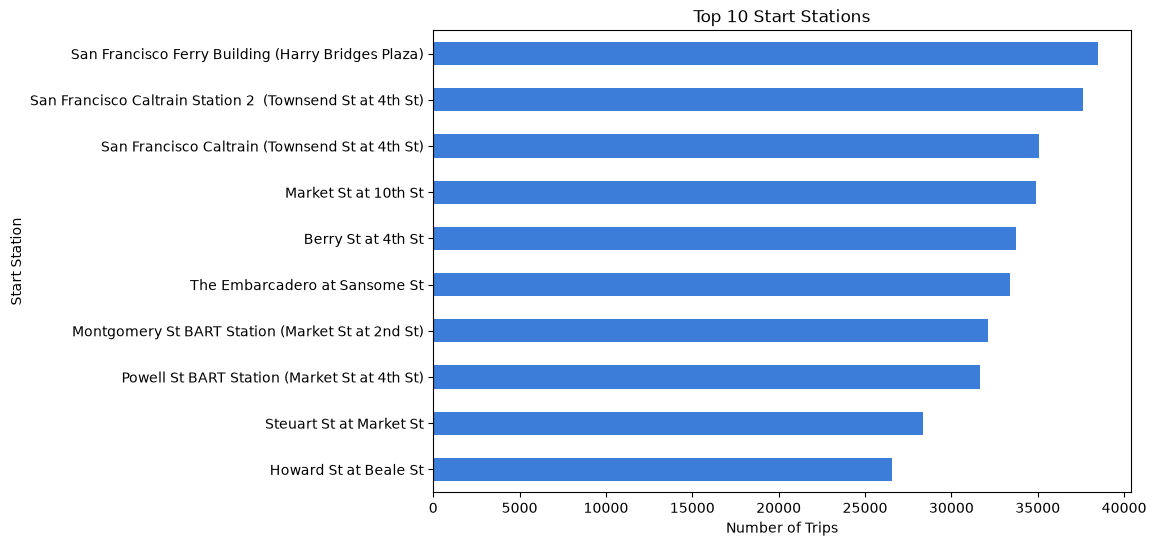

In [20]:
# Chart - 8 visualization code
plt.figure(figsize=(9,6))
df.start_station_name.value_counts().head(10).sort_values().plot(kind='barh', color='#3b7dd8')
plt.xlabel('Number of Trips')
plt.ylabel('Start Station')
plt.title('Top 10 Start Stations')
plt.show()

##### 1. Why did you pick the specific chart?

A horizontal bar chart was used because station names are long text labels, which are easier to read on the y-axis, and it clearly ranks the top stations by trip count.

##### 2. What is/are the insight(s) found from the chart?

A small number of stations - mostly located near transit hubs and downtown areas - account for a disproportionately large share of total trips, compared to the thousands of other stations.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. These high-traffic stations need priority for bike restocking and maintenance to avoid running out of bikes or docks. This also identifies good locations for future station expansion or advertising partnerships.

#### Chart - 9

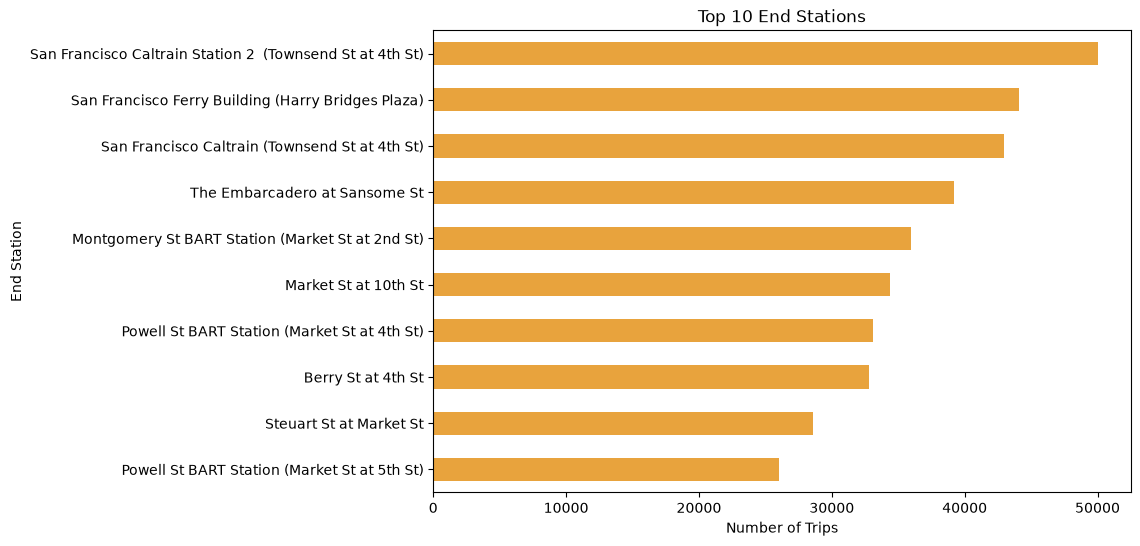

In [21]:
# Chart - 9 visualization code
plt.figure(figsize=(9,6))
df.end_station_name.value_counts().head(10).sort_values().plot(kind='barh', color='#e8a33d')
plt.xlabel('Number of Trips')
plt.ylabel('End Station')
plt.title('Top 10 End Stations')
plt.show()

##### 1. Why did you pick the specific chart?

Similar to the start station chart, a horizontal bar chart works best for comparing trip counts across long station name labels.

##### 2. What is/are the insight(s) found from the chart?

The top end stations largely overlap with the top start stations, confirming that certain central/downtown locations act as major hubs for both picking up and dropping off bikes.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Since these hubs see both high pickups and drop-offs, the company can design smarter rebalancing routes between these key stations, reducing the cost and effort of manually redistributing bikes across the city.

#### Chart - 10

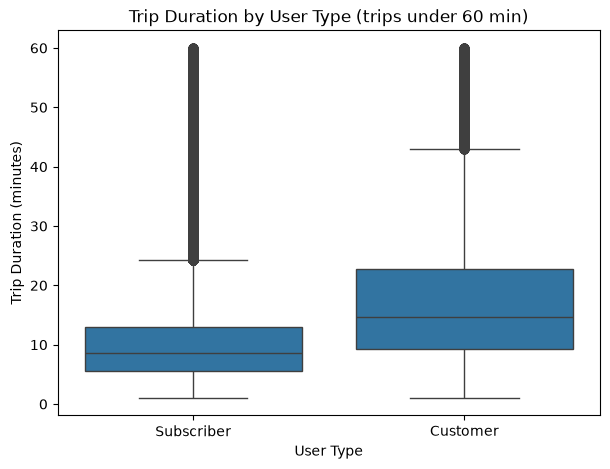

In [22]:
# Chart - 10 visualization code
plt.figure(figsize=(7,5))
sb.boxplot(x='user_type', y='duration_min', data=df[df.duration_min <= 60])
plt.xlabel('User Type')
plt.ylabel('Trip Duration (minutes)')
plt.title('Trip Duration by User Type (trips under 60 min)')
plt.show()

##### 1. Why did you pick the specific chart?

A box plot was chosen because it compares the distribution (median, spread, outliers) of a numeric variable (duration) across two categories (user type) in a single clear view.

##### 2. What is/are the insight(s) found from the chart?

Customers (casual riders) tend to have longer and more variable trip durations, while Subscribers have shorter, more consistent trip durations - consistent with Subscribers using bikes for quick commutes and Customers using them more for leisure.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. This suggests different pricing models could work well - shorter flat-rate pricing for Subscribers optimized for commutes, and time-based leisure pricing for Customers, maximizing revenue from each segment's actual usage pattern.

#### Chart - 11

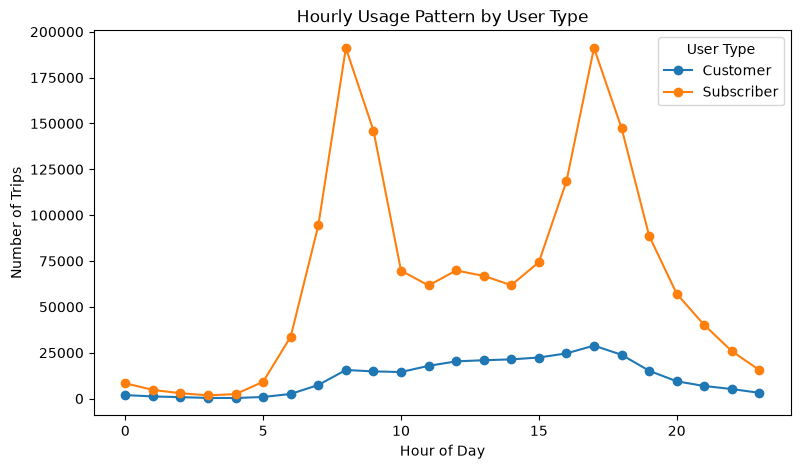

In [23]:
# Chart - 11 visualization code
plt.figure(figsize=(9,5))
hourly_by_type = df.groupby(['start_hour','user_type']).size().unstack()
hourly_by_type.plot(kind='line', marker='o', ax=plt.gca())
plt.xlabel('Hour of Day')
plt.ylabel('Number of Trips')
plt.title('Hourly Usage Pattern by User Type')
plt.legend(title='User Type')
plt.show()

##### 1. Why did you pick the specific chart?

A multi-line chart was used to compare how two categories (Subscriber, Customer) behave across a continuous sequence (hour of day) at the same time.

##### 2. What is/are the insight(s) found from the chart?

Subscribers show sharp double peaks at 8 AM and 5-6 PM (commute pattern), while Customers show a flatter, more spread-out usage pattern throughout the day with a gentle peak in the afternoon - consistent with leisure/tourist use.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. This confirms two distinct customer segments with different needs. The business can run targeted campaigns - commute-focused perks for Subscribers, and afternoon/weekend leisure packages for Customers - to grow each segment appropriately.

#### Chart - 12

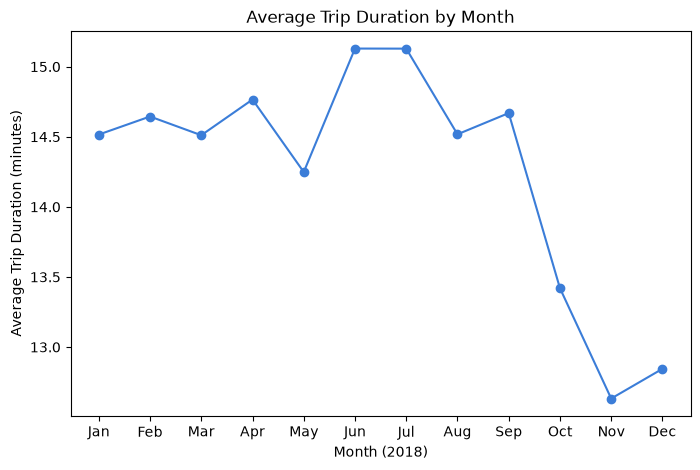

In [24]:
# Chart - 12 visualization code
plt.figure(figsize=(8,5))
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
avg_dur = df.groupby('start_month').duration_min.mean()
plt.plot([month_names[i-1] for i in avg_dur.index], avg_dur.values, marker='o', color='#3b7dd8')
plt.xlabel('Month (2018)')
plt.ylabel('Average Trip Duration (minutes)')
plt.title('Average Trip Duration by Month')
plt.show()

##### 1. Why did you pick the specific chart?

A line chart was used again since month has a natural order, making it easy to see how average trip duration trends across the year.

##### 2. What is/are the insight(s) found from the chart?

Average trip duration tends to be higher during warmer months (summer) compared to colder months (winter), suggesting weather encourages longer, more leisurely rides.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Longer average trips in summer could support seasonal pricing adjustments or promotions (e.g., day passes) during warmer months when riders are naturally inclined to ride longer.

#### Chart - 13

<Figure size 700x500 with 0 Axes>

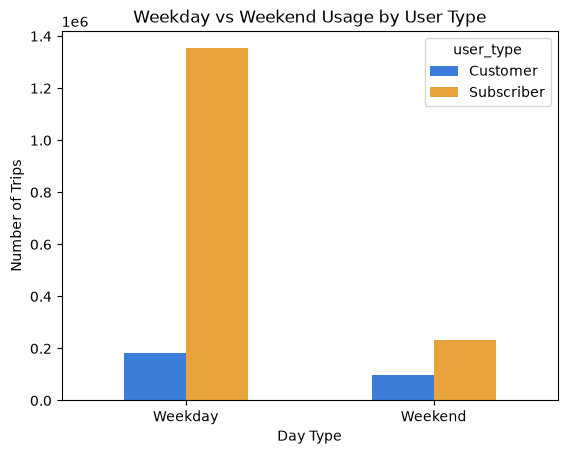

In [25]:
# Chart - 13 visualization code
plt.figure(figsize=(7,5))
weekend_by_type = df.groupby(['is_weekend','user_type']).size().unstack()
weekend_by_type.index = ['Weekday','Weekend']
weekend_by_type.plot(kind='bar', color=['#3b7dd8','#e8a33d'])
plt.xlabel('Day Type')
plt.ylabel('Number of Trips')
plt.title('Weekday vs Weekend Usage by User Type')
plt.xticks(rotation=0)
plt.show()

##### 1. Why did you pick the specific chart?

A grouped bar chart was used to compare two categories (user type) across two conditions (weekday vs weekend) side by side.

##### 2. What is/are the insight(s) found from the chart?

Subscribers ride far more on weekdays than weekends, reinforcing their commute-driven usage. Customers show a relatively more balanced (even slightly higher proportional) usage on weekends, supporting their leisure-oriented behavior.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. This confirms that weekend-focused marketing should target Customers/casual riders (e.g., weekend leisure passes), while weekday service reliability should be prioritized for Subscribers to retain their commute loyalty.

#### Chart - 14 - Correlation Heatmap

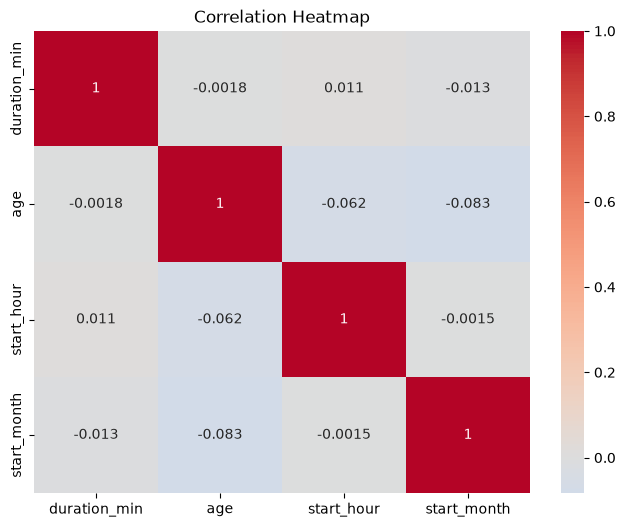

In [26]:
# Correlation Heatmap visualization code
plt.figure(figsize=(8,6))
corr_cols = ['duration_min', 'age', 'start_hour', 'start_month']
corr_matrix = df[corr_cols].corr()
sb.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

##### 1. Why did you pick the specific chart?

A heatmap was chosen because it's the standard way to visualize correlation between multiple numeric variables at once, using color intensity to show strength and direction of relationships.

##### 2. What is/are the insight(s) found from the chart?

The correlations between duration, age, hour, and month are all quite weak (close to 0), meaning these numeric variables don't have strong linear relationships with each other. Trip behavior is driven more by categorical factors like user_type and day of week than by these numeric variables alone.

#### Chart - 15 - Pair Plot

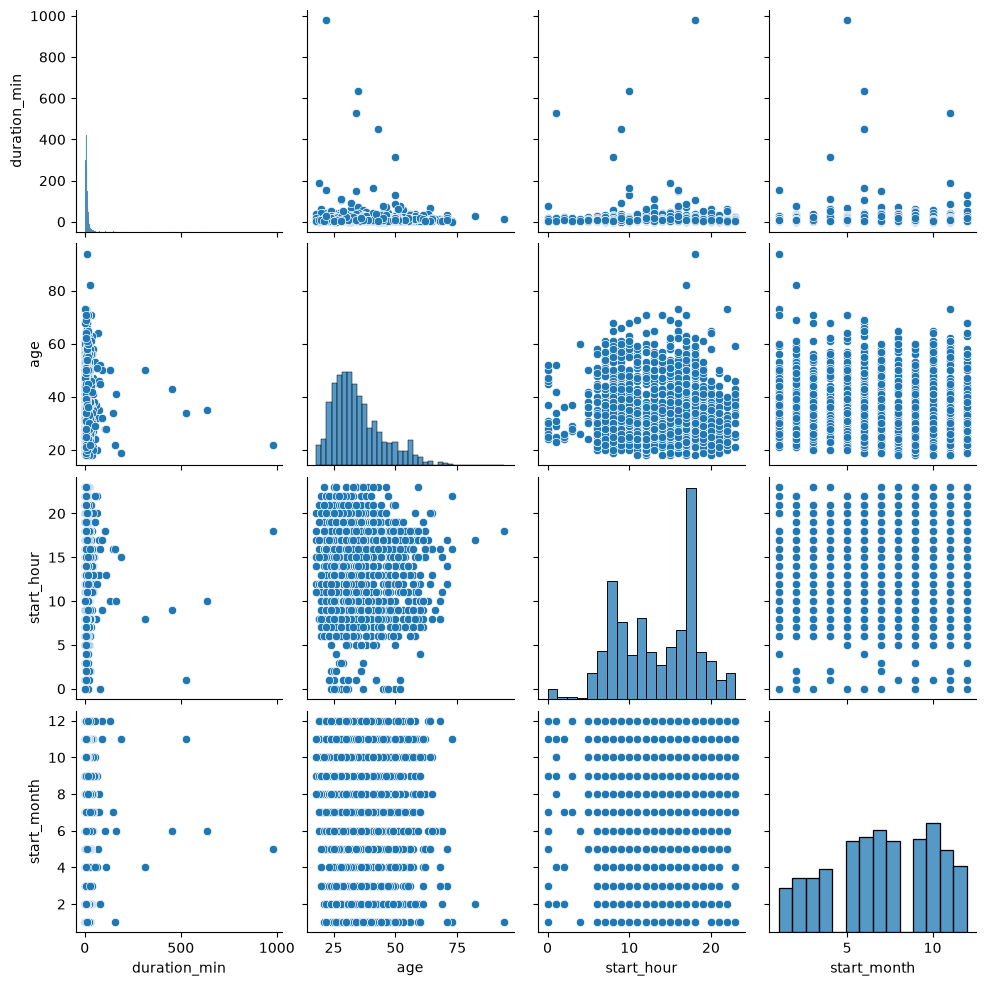

In [27]:
# Pair Plot visualization code
sample_df = df[['duration_min','age','start_hour','start_month']].dropna().sample(2000, random_state=42)
sb.pairplot(sample_df, diag_kind='hist')
plt.show()

##### 1. Why did you pick the specific chart?

A pair plot was chosen because it shows relationships between all pairs of numeric variables at once, along with their individual distributions on the diagonal - useful for spotting any hidden patterns across multiple variables simultaneously.

##### 2. What is/are the insight(s) found from the chart?

The pair plot confirms no strong linear relationships between duration, age, hour, and month - consistent with the correlation heatmap. Each variable's individual distribution (diagonal) matches what was seen in earlier individual charts (e.g., right-skewed duration, age clustering around 25-40).

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

Based on the analysis, GoBike usage is heavily commute-driven, with two clear peaks at 8-9 AM and 5-6 PM on weekdays, mostly from Subscribers. Customers (casual riders) show more leisure-oriented, weekend-friendly usage with longer trip durations. A small set of central stations handle a disproportionate share of trips. To grow the business: (1) prioritize bike rebalancing at top stations before peak commute hours, (2) run weekend/leisure promotions to convert Customers into Subscribers, (3) use seasonal patterns to plan fleet maintenance during low-demand winter months, and (4) investigate outlier long-duration trips as potential lost/damaged bikes.

# **Conclusion**

This EDA of 1.86 million Ford GoBike trips from 2018 revealed clear commute-driven usage patterns, a strong subscriber base (about 85% of trips), and distinct behavioral differences between Subscribers and Customers. These insights can guide station planning, pricing strategy, and targeted marketing to grow ridership across all rider segments.

### ***Hurrah! You have successfully completed your EDA Capstone Project !!!***